# MISC

In [1]:
import os, sys
import pandas as pd
import numpy as np
import json
import shutil
import matplotlib.pyplot as plt
from datetime import datetime
from concurrent.futures import ThreadPoolExecutor, as_completed

notebook_dir = os.getcwd()  # Gets test folder path
project_dir = os.path.dirname(notebook_dir)  # Gets Project folder path
sys.path.append(project_dir)

from subproblems import *
from utils import *

In [2]:
# constraint based post-proc function
def post_process_constraint(pred, param, pros_decision = None, sce_idx = None, p2p_bal = True):
    h = int(param['hour'])
    P2PTrade = param['P2PTrade']
    P_load = param['load_demamd']
    PI_buy = param['buy_priority']
    PI_sell = param['sell_priority']
    ub_CESc, lb_CESc = param['ub_CESc'], param['lb_CESc']
    ub_CESd, lb_CESd = param['ub_CESd'], param['lb_CESd']

    pred = pred.reshape(-1, 192, 32) 

    qc, qd, P_buy, P_sell = [pred[:, i*h:(i+1)*h, :] for i in range(4)]
    if pros_decision is not None: Pg_buy, Pg_sell  = [pros_decision[i*h:(i+1)*h, :] for i in range(2)]

    # Post-process for boundary
    qc = np.clip(qc, a_min=lb_CESc[0], a_max=ub_CESc[0])
    qd = np.clip(qd, a_min=lb_CESd[0], a_max=ub_CESd[0])
    P_buy = np.clip(P_buy, a_min=0, a_max=None)
    P_sell = np.clip(P_sell, a_min=0, a_max=None)
    # print(qc.shape, qd.shape, P_buy.shape, P_sell.shape)

    # Post-process for P2P trade hour
    start, end_ = P2PTrade 
    for t in range(0, start): # 0 ~ 15 -> 1 ~ 16
        P_buy[:,t,:] = 0
        P_sell[:,t,:] = 0
    for t in range(end_ - 1, h):  # 37 ~ 47 -> 38 ~ 48
        P_buy[:,t,:] = 0
        P_sell[:,t,:] = 0

    if p2p_bal == True:
        # Post-process for priority based P2P balancing
        for sce in range(pred.shape[0]):
            for t in range(h):
                p2p_balance = P_buy[sce,t,:].sum() - P_sell[sce,t,:].sum()
                # print(f"Scenario {sce}, Hour {t}: P2P Balance = {p2p_balance}")
                bp_idx_sorted = np.argsort(PI_buy[t,:])  # Ascending order as highest priority has the lowest value
                sp_idx_sorted = np.argsort(PI_sell[t,:])[::-1]  # Descending order as highest priority has the highest value
                    
                if p2p_balance < 0: # more selling than buying, need to increase buying or decrease selling
                    # Adjust P_sell to balance P2P trade
                    for idx in sp_idx_sorted:
                        if p2p_balance >= 0:
                            break
                        reduction = min(P_sell[sce, t, idx], -p2p_balance)  # Reduce as much as needed or as much as possible
                        P_sell[sce, t, idx] -= reduction
                        p2p_balance += reduction
                    
                    # If still imbalance, adjust P_buy to balance P2P trade
                    for idx in bp_idx_sorted:
                        if p2p_balance >= 0:
                            break
                        increase = min(ub_CESd - qd[sce, t, idx], -p2p_balance)  # Increase as much as needed or as much as possible within bounds
                        P_buy[sce, t, idx] += increase
                        p2p_balance += increase

                if p2p_balance > 0: # more buying than selling, need to increase selling or decrease buying
                    # Adjust P_buy to balance P2P trade
                    for idx in sp_idx_sorted:
                        if p2p_balance <= 0:
                            break
                        reduction = min(P_buy[sce, t, idx], p2p_balance)  # Reduce as much as needed or as much as possible
                        P_buy[sce, t, idx] -= reduction
                        p2p_balance -= reduction

                    # If still imbalance, adjust P_sell to balance P2P trade
                    for idx in bp_idx_sorted:
                        if p2p_balance <= 0:
                            break
                        increase = min(ub_CESc - qc[sce, t, idx], p2p_balance)  # Increase as much as needed or as much as possible within bounds
                        P_sell[sce, t, idx] += increase
                        p2p_balance -= increase

    return np.concatenate([qc, qd, P_buy, P_sell], axis=1)
                

In [3]:
# constraint feasibility check function
def check_constraint_feasibility_np(preds, external_data_np, tolerance=1e-3, ver='Original'):
    """
    Checks if provided predictions satisfy physical constraints using NumPy.
    
    Args:
        preds: NumPy array of denormalized predictions shape (Batch, 6144)
        indices: NumPy array or list of indices 
        external_data_np: NumPy array shape (Total_Scenarios, 48, 32)
        tolerance: Acceptable error margin
    """
    # 1. Ensure shape is (Batch, 192, 32)
    # 192 features: [Charge(48), Discharge(48), Buy(48), Sell(48)]
    # We use .reshape to handle both (Batch, 1, 6144) and (Batch, 6144)
    pred_matrix = preds.reshape(-1, 192, 32)
    
    # 2. Extract Variables (Batch, 48, 32)
    p_chg  = pred_matrix[:, 0:48, :]
    p_dis  = pred_matrix[:, 48:96, :]
    p_buy  = pred_matrix[:, 96:144, :]
    p_sell = pred_matrix[:, 144:192, :]
    
    # --- CHECK 1: Market Balance (Total Buy = Total Sell) ---
    total_buy = np.sum(p_buy, axis=2)   # Sum across 32 users -> (Batch, 48)
    total_sell = np.sum(p_sell, axis=2) # Sum across 32 users -> (Batch, 48)
    
    diff_balance = np.abs(total_buy - total_sell)
    max_bal_err = np.max(diff_balance)
    avg_bal_err = np.mean(diff_balance)
    
    # --- CHECK 2: Net Load Clearing (Supply == Demand) ---
    # Eq: (Buy - Sell) + (Discharge - Charge) = NetLoad
    energy_supplied = (p_buy - p_sell) + (p_dis - p_chg)
    
    # Fetch specific external data for this batch
    batch_net_load = external_data_np # (Batch, 48, 32)
    
    diff_clearing = np.abs(energy_supplied - batch_net_load)
    max_clr_err = np.max(diff_clearing)
    avg_clr_err = np.mean(diff_clearing)

    # --- Summary Report ---
    print("-" * 50)
    print(f"PHYSICAL CONSTRAINT REPORT ({ver})")
    print("-" * 50)
    
    passed_bal = max_bal_err < tolerance
    print(f"1. Market Balance: {'✅ PASS' if passed_bal else '❌ FAIL'}")
    print(f"   Max Error: {max_bal_err:.6f} | Avg Error: {avg_bal_err:.6f}")
    
    passed_clr = max_clr_err < tolerance
    print(f"\n2. Net Load Clearing: {'✅ PASS' if passed_clr else '❌ FAIL'}")
    print(f"   Max Error: {max_clr_err:.6f} | Avg Error: {avg_clr_err:.6f}")
    print("-" * 50)
    
    return {
        "balance_passed": passed_bal,
        "clearing_passed": passed_clr,
        "max_balance_error": max_bal_err,
        "max_clearing_error": max_clr_err
    }

In [4]:
# optimal_iter folder summarize
def gather_results(datapath, start_sce_save, end_sce_save):
    all_de, all_dr, all_pe, all_pr, all_obj, all_opt, all_run = [], [], [], [], [], [], []
    i = start_sce_save
    time_iter = False

    path_optiter = f"{datapath}/location/optimal_iter_{end_sce_save-4}to{end_sce_save}sce.csv"
    path_runtime = f"{datapath}/location/execution_time_{end_sce_save-4}to{end_sce_save}sce.csv"

    exe_last = pd.read_csv(path_runtime).values

    if exe_last.flatten().shape[0] == end_sce_save:
        shutil.copy(path_optiter, f"{datapath}/optimal_iter/optimal_iter_{start_sce_save}to{end_sce_save}sce.csv")
        shutil.copy(path_runtime, f"{datapath}/optimal_iter/execution_time_{start_sce_save}to{end_sce_save}sce.csv")
    else:
        time_iter = True

    while i <= end_sce_save - 4:
        first = i
        last = i + 4
        
        path_de = f"{datapath}/location/dual_error_{first}to{last}sce.csv"
        path_dr = f"{datapath}/location/dual_residual_{first}to{last}sce.csv"
        path_pe = f"{datapath}/location/primal_error_{first}to{last}sce.csv"
        path_pr = f"{datapath}/location/primal_residual_{first}to{last}sce.csv"
        path_obj = f"{datapath}/location/objective_value_{first}to{last}sce.csv"
        
        # Read CSVs
        df_de = pd.read_csv(path_de).values
        df_dr = pd.read_csv(path_dr).values
        df_pe = pd.read_csv(path_pe).values
        df_pr = pd.read_csv(path_pr).values
        df_obj = pd.read_csv(path_obj).values

        all_de = np.concatenate((all_de, df_de), axis=0) if len(all_de) > 0 else df_de
        all_dr = np.concatenate((all_dr, df_dr), axis=0) if len(all_dr) > 0 else df_dr
        all_pe = np.concatenate((all_pe, df_pe), axis=0) if len(all_pe) > 0 else df_pe
        all_pr = np.concatenate((all_pr, df_pr), axis=0) if len(all_pr) > 0 else df_pr
        all_obj = np.concatenate((all_obj, df_obj), axis=0) if len(all_obj) > 0 else df_obj
        
        if time_iter:
            path_optiter = f"{datapath}/location/optimal_iter_{first}to{last}sce.csv"
            path_runtime = f"{datapath}/location/execution_time_{first}to{last}sce.csv"

            df_opt = pd.read_csv(path_optiter).values
            df_run = pd.read_csv(path_runtime).values

            all_opt = np.concatenate((all_opt, df_opt), axis=0) if len(all_opt) > 0 else df_opt
            all_run = np.concatenate((all_run, df_run), axis=0) if len(all_run) > 0 else df_run

        i += 5

    df_all_de = pd.DataFrame(all_de)
    df_all_dr = pd.DataFrame(all_dr)
    df_all_pe = pd.DataFrame(all_pe)
    df_all_pr = pd.DataFrame(all_pr)
    df_all_obj = pd.DataFrame(all_obj)

    df_all_de.to_csv(f"{datapath}/optimal_iter/dual_error_{start_sce_save}to{end_sce_save}sce.csv", index=False)
    df_all_dr.to_csv(f"{datapath}/optimal_iter/dual_residual_{start_sce_save}to{end_sce_save}sce.csv", index=False)
    df_all_pe.to_csv(f"{datapath}/optimal_iter/primal_error_{start_sce_save}to{end_sce_save}sce.csv", index=False)
    df_all_pr.to_csv(f"{datapath}/optimal_iter/primal_residual_{start_sce_save}to{end_sce_save}sce.csv", index=False)
    df_all_obj.to_csv(f"{datapath}/optimal_iter/objective_value_{start_sce_save}to{end_sce_save}sce.csv", index=False)

    if time_iter:
        df_all_opt = pd.DataFrame(all_opt)
        df_all_run = pd.DataFrame(all_run)

        df_all_opt.to_csv(f"{datapath}/optimal_iter/optimal_iter_{start_sce_save}to{end_sce_save}sce.csv", index=False)
        df_all_run.to_csv(f"{datapath}/optimal_iter/execution_time_{start_sce_save}to{end_sce_save}sce.csv", index=False)

In [5]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def plot_with_std(primal_test, primal_eval, dual_test, dual_eval, window=50):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

    def add_shaded_moving_avg(ax, data, label, color, window_size):
        # 1. Calculate raw stats
        raw_mean = np.nanmean(data, axis=0)
        raw_std = np.nanstd(data, axis=0)
        
        # 2. Apply Moving Average (Convolution)
        def moving_avg(x, w):
            return np.convolve(x, np.ones(w), 'valid') / w
        
        mean_ma = moving_avg(raw_mean, window_size)
        std_ma = moving_avg(raw_std, window_size)
        x = np.arange(len(mean_ma))
        
        # 3. Plot smoothed line and shaded area
        line, = ax.plot(x, mean_ma, label=label, color=color, linewidth=2)
        ax.fill_between(x, mean_ma - std_ma, mean_ma + std_ma, color=color, alpha=0.15)
        return x, mean_ma, color

    # --- Plot 1: Primal ---
    x_pt, m_pt, c_pt = add_shaded_moving_avg(ax1, primal_test, "Test (2411)", "blue", window)
    x_pe, m_pe, c_pe = add_shaded_moving_avg(ax1, primal_eval, "Eval (673)", "orange", window)
    ax1.set_title("Primal Residual (Moving Avg ± STD)")

    # --- Plot 2: Dual ---
    x_dt, m_dt, c_dt = add_shaded_moving_avg(ax2, dual_test, "Test (2411)", "green", window)
    x_de, m_de, c_de = add_shaded_moving_avg(ax2, dual_eval, "Eval (673)", "red", window)
    ax2.set_title("Dual Residual (Moving Avg ± STD)")

    for i, ax in enumerate([ax1, ax2]):
        ax.set_yscale('log')
        ax.set_ylim(10e-7, 1)
        ax.axhline(y=1e-3, color='black', linestyle=':', linewidth=1.5, label='Threshold ($10^{-3}$)')
        ax.set_xlabel("Iteration")
        ax.set_ylabel("Residual")
        ax.grid(True, which="both", linestyle="--", alpha=0.4)
        ax.legend(loc='upper right')

        # --- ADD INSET ZOOM (The "Publication Pro" Touch) ---
        # Position: 30% width, 30% height, location 10 (center right-ish)
        axins = inset_axes(ax, width="35%", height="35%", loc='center right', borderpad=2)
        
        # Get data for inset (First 800 iterations are usually most interesting)
        if i == 0: # Primal Inset
            axins.plot(x_pt[:800], m_pt[:800], color=c_pt)
            axins.plot(x_pe[:800], m_pe[:800], color=c_pe)
        else: # Dual Inset
            axins.plot(x_dt[:800], m_dt[:800], color=c_dt)
            axins.plot(x_de[:800], m_de[:800], color=c_de)
            
        axins.axhline(y=1e-3, color='black', linestyle=':', linewidth=1)
        axins.set_yscale('log')
        axins.set_xlim(0, 600) # Zoom into the first 600 iterations
        axins.set_ylim(1e-4, 1) # Zoom into the threshold crossing
        axins.tick_params(labelsize=8)
        axins.grid(True, linestyle="--", alpha=0.3)

    plt.tight_layout()
    plt.show()

# Data Loading

In [6]:
datapath = r"D:\Jacky\Data Output\ADMM_P2P\Database\LP_PrioGO_test_100_OldSame_latest"

with open(f'{datapath}/config.json', 'r') as file:
    config = json.load(file)

SCE_START, SCE_END = config["sce_start"], config["sce_end"]
BUS_SYS = 33
MAX_ITER = 5000
PRIMAL_TOL, DUAL_TOL = 1e-3, 1e-3
BATTERY_CAP = 2
P2P_TRADE = (16, 38)
SOLAR_SCALER = 1.5
DATA_DIR = r"D:\Jacky\Python\ADMM_P2P_Python\data"

primal = np.load(f"{datapath}/predictions/primal_pred.npy")
dual = np.load(f"{datapath}/predictions/dual_pred.npy")
decVar = np.load(f"{datapath}/training ready/decisionGRU.npy")
power_load = pd.read_csv(f"{DATA_DIR}/Power Consumption_33_bus.csv", header=0).values / 2
solar_sce = pd.read_csv(f"{DATA_DIR}/Solar_interpolated_6000.csv", header=0).values[SCE_START-1:SCE_END]

decVar = decVar[:,:,:,-1]
grid_trade = decVar[:,:96,:]
hour, num_user = power_load.shape

del decVar

In [7]:
# 1. Prepare Raw External Data (Before shuffling)
solar = solar_sce * SOLAR_SCALER
net_load = np.tile(power_load, (SCE_END-SCE_START+1, 1, 1))
pros_solar = int(np.ceil(num_user / 2)) - 1 # to match with Julia 1-inclusive indexing 
net_load[:, :, pros_solar:] -= solar[:, :, np.newaxis] # Shape: (1000, 48, 32)
net_load_wGrid = net_load.copy() # for later use in physics loss calculation

# 2. Calculate Grid Trade Variable (Sell - Buy) in Real Units
grid_trade = grid_trade[:,48:,:] - grid_trade[:,:48,:]

# 3. Include the final Grid Trade into Net Load (for training physics loss)
net_load_wGrid += grid_trade

net_load_wGrid.shape

(100, 48, 32)

In [8]:
data = load_scenario_data(DATA_DIR, BUS_SYS)

# === CES battery bounds ===
ub_CES = np.full((hour, num_user), BATTERY_CAP)
lb_CES = np.zeros((hour, num_user))

ub_CESc = np.full((hour, num_user), BATTERY_CAP / 3)  # charging bound
lb_CESc = np.zeros((hour, num_user))

ub_CESd = np.full((hour, num_user), BATTERY_CAP / 3)  # discharging bound
lb_CESd = np.zeros((hour, num_user))

# === Initialize other key parameters ===
beta_tnb = 1
P_CES0 = np.full(num_user, BATTERY_CAP / 2)
efficiency_CES = 1.0

# === Build prosumer parameters ===
param = {
    "ub_CES": ub_CES,
    "lb_CES": lb_CES,
    "ub_CESc": ub_CESc,
    "lb_CESc": lb_CESc,
    "ub_CESd": ub_CESd,
    "lb_CESd": lb_CESd,
    "hour": hour,
    "beta_tnb": beta_tnb,
    "CES0": P_CES0,
    "P2PTrade": P2P_TRADE,
    "efficiency_CES": efficiency_CES,
    "buy_priority": data["buy_priority"].T,
    "sell_priority": data["sell_priority"].T,
    "load_demamd": net_load.T,  # matches Julia's net_load'
}

# Feasibility Checks

In [9]:
feasibility_report = check_constraint_feasibility_np(primal, net_load_wGrid, tolerance=1e-3)
primal = post_process_constraint(primal, param, p2p_bal=True)
feasibility_report = check_constraint_feasibility_np(primal, net_load_wGrid, tolerance=1e-3, ver='Post-Processed')

--------------------------------------------------
PHYSICAL CONSTRAINT REPORT (Original)
--------------------------------------------------
1. Market Balance: ❌ FAIL
   Max Error: 0.350229 | Avg Error: 0.024533

2. Net Load Clearing: ❌ FAIL
   Max Error: 0.557936 | Avg Error: 0.025360
--------------------------------------------------
--------------------------------------------------
PHYSICAL CONSTRAINT REPORT (Post-Processed)
--------------------------------------------------
1. Market Balance: ✅ PASS
   Max Error: 0.000002 | Avg Error: 0.000000

2. Net Load Clearing: ❌ FAIL
   Max Error: 0.507859 | Avg Error: 0.025473
--------------------------------------------------


In [10]:
# save post-processed predictions
np.save(f"{datapath}/predictions/primal_pred_post.npy", primal)

# Performance Logging

In [7]:
# npz format
datapath = r"D:\Jacky\Data Output\ADMM_P2P\Database\Test and Eval\LP_PrioGO_test_100_OldSame_latest_lowThreshold"
opt_iter = np.load(f"{datapath}/optimal_iter/conv_iter.npz")
obj_var = np.load(f"{datapath}/optimal_iter/obj_var.npz")
exe_time = np.load(f"{datapath}/optimal_iter/runtime.npz")

indices = [int(x-2) for x in opt_iter]
opt_obj_var = [obj_var[sce, i] for sce, i in enumerate(indices)]

print(opt_obj_var)
print(opt_iter)
print(exe_time)

# 1. Create a dictionary to map data to column names
data = {
    'Objective_Value': opt_obj_var,
    'Iterations': opt_iter,
    'Execution_Time': exe_time
}

# 2. Create the DataFrame
df = pd.DataFrame(data)

# 3. for evaluation
df.to_csv(r"D:\Jacky\Python\ADMM_P2P_Python\output\ML_Results.xlsx", index=False)

# 4. for backing up
df.to_csv(f"{datapath}/optimal_iter/ML_Results.csv", index=False)

[446.9677743739291, 448.21989222373503, 472.35452273437056, 461.17109108195444, 448.13160512953897, 458.1935245429535, 464.2755729014533, 449.77732683056803, 453.94052987249626, 456.890131029035, 434.3865476257473, 451.70431070860246, 463.09342183586756, 451.6559202402421, 460.10714428803703, 461.69221431711406, 450.1868688554999, 455.4150929311501, 463.1982144226349, 466.3170856794075, 462.2710306686877, 454.55853186379136, 463.7132235398734, 451.545008709099, 448.9966449059673, 448.2944596026815, 455.23870712513525, 447.04034611988277, 450.85168194076005, 443.74266074498235, 468.51212669918544, 459.8413548512186, 455.7176868611583, 448.81295596364623, 456.40153503267163, 459.6866048049008, 446.0089236636749, 450.5934451915933, 445.1850416267637, 452.49670035104276, 457.667380588163, 462.9432091416058, 440.4916739032415, 456.76037858968397, 444.6959533167204, 457.6298556974522, 460.52080545869495, 448.31519783312797, 455.83929283566573, 472.27119946425836, 457.4805131500526, 455.87520

In [7]:
# csv format
datapath = r"D:\Jacky\Data Output\ADMM_P2P\Database\Train\LP_PrioGO_train_InterGen_1000sce"
with open(f'{datapath}/config.json', 'r') as file:
    config = json.load(file)
start_sce_save, end_sce_save = config["sce_start"], config["sce_end"]
gather_results(datapath, start_sce_save, end_sce_save)

opt_iter = pd.read_csv(f"{datapath}/optimal_iter/optimal_iter_{start_sce_save}to{end_sce_save}sce.csv").values.flatten()
obj_var = pd.read_csv(f"{datapath}/optimal_iter/objective_value_{start_sce_save}to{end_sce_save}sce.csv").values
exe_time = pd.read_csv(f"{datapath}/optimal_iter/execution_time_{start_sce_save}to{end_sce_save}sce.csv").values.flatten()

indices = [int(x-2) for x in opt_iter]
opt_obj_var = [obj_var[sce, i] for sce, i in enumerate(indices)]

if len(exe_time) != end_sce_save - start_sce_save + 1:
    print("Warning: Execution time length does not match number of scenarios. Please check the data.")
else:
    print(opt_obj_var)
    print(opt_iter)
    print(exe_time)

    # 1. Create a dictionary to map data to column names
    data = {
        'Objective_Value': opt_obj_var,
        'Iterations': opt_iter,
        'Execution_Time': exe_time
    }

    # 2. Create the DataFrame
    df = pd.DataFrame(data)

    # 3. for evaluation
    df.to_csv(r"D:\Jacky\Python\ADMM_P2P_Python\output\ML_Results.xlsx", index=False)

    # 4. for backing up
    df.to_csv(f"{datapath}/optimal_iter/ML_Results.csv", index=False)

[32.57115525675439, 59.63728051367156, 85.71970069985164, 120.22582218821438, 138.27968492567652, 175.6527401398651, 188.78629172580204, 223.5253104996556, 262.33755984910755, 279.89068123100856, 302.0241018598639, 355.2625852257627, 377.8505110407188, 385.28303343004393, 428.64900934669663, 446.47575504881513, 29.952279596604377, 56.07292360004916, 88.13836755227122, 119.34909608180033, 143.40548719858143, 166.83196987349524, 211.41381994830064, 223.44216109038737, 263.17395337174463, 273.80785095080654, 329.41067526274395, 349.2765166904059, 372.0225758677064, 413.1961194879507, 426.2334228955562, 439.44893919822096, 30.612562240862275, 57.75792635094731, 83.76068472789419, 119.7916979285254, 143.17098033888905, 159.86722267863357, 194.0752697540321, 231.8872371656216, 260.63785285853675, 288.21268648387263, 301.80671895728085, 330.09945330807574, 353.5598080409419, 392.8386889445717, 421.417592124557, 448.9701615353872, 30.16365423010217, 57.91668005459767, 77.1251347983044, 122.121

In [6]:
testdatapath = r"D:\Jacky\Data Output\ADMM_P2P\Database\Test and Eval\LP_PrioGO-LDF-mulCES-4dec_test_InterGen_100sce"
evaldatapath = r"D:\Jacky\Data Output\ADMM_P2P\Database\Test and Eval\Eval_NDNN-SAM-T9_PrioGO-LDF-mulCES-4dec_InterGen_raw_WS_100sce"

with open(f'{testdatapath}/config.json', 'r') as file:
    config_test = json.load(file)
start_sce_save, end_sce_save = config_test["sce_start"], config_test["sce_end"]
# gather_results(testdatapath, start_sce_save, end_sce_save)
with open(f'{evaldatapath}/config.json', 'r') as file:
    config_eval = json.load(file)
start_sce_save, end_sce_save = config_eval["sce_start"], config_eval["sce_end"]
gather_results(evaldatapath, start_sce_save, end_sce_save)

if config_test["save_csv"]:
    start_sce_test, end_sce_test = config_test["sce_start"], config_test["sce_end"]
    iter_test = pd.read_csv(f"{testdatapath}/optimal_iter/optimal_iter_{start_sce_test}to{end_sce_test}sce.csv").values.flatten()
    obj_test = pd.read_csv(f"{testdatapath}/optimal_iter/objective_value_{start_sce_test}to{end_sce_test}sce.csv").values
    time_test = pd.read_csv(f"{testdatapath}/optimal_iter/execution_time_{start_sce_test}to{end_sce_test}sce.csv").values.flatten()

    indices = [int(x-2) for x in iter_test]
    opt_obj_test = np.array([obj_test[sce, i] for sce, i in enumerate(indices)])
else:
    iter_test = np.load(f"{testdatapath}/optimal_iter/conv_iter.npz")
    obj_test = np.load(f"{testdatapath}/optimal_iter/obj_var.npz")
    time_test = np.load(f"{testdatapath}/optimal_iter/runtime.npz")

    indices = [int(x-2) for x in iter_test]
    opt_obj_test = np.array([obj_test[sce, i] for sce, i in enumerate(indices)])

if config_eval["save_csv"]:
    start_sce_eval, end_sce_eval = config_eval["sce_start"], config_eval["sce_end"]
    iter_eval = pd.read_csv(f"{evaldatapath}/optimal_iter/optimal_iter_{start_sce_eval}to{end_sce_eval}sce.csv").values.flatten()
    obj_eval = pd.read_csv(f"{evaldatapath}/optimal_iter/objective_value_{start_sce_eval}to{end_sce_eval}sce.csv").values
    time_eval = pd.read_csv(f"{evaldatapath}/optimal_iter/execution_time_{start_sce_eval}to{end_sce_eval}sce.csv").values.flatten()

    indices = [int(x-2) for x in iter_eval]
    opt_obj_eval = np.array([obj_eval[sce, i] for sce, i in enumerate(indices)])
else:
    iter_eval = np.load(f"{evaldatapath}/optimal_iter/conv_iter.npz")
    obj_eval = np.load(f"{evaldatapath}/optimal_iter/obj_var.npz")
    time_eval = np.load(f"{evaldatapath}/optimal_iter/runtime.npz")

    indices = [int(x-2) for x in iter_eval]
    opt_obj_eval = np.array([obj_eval[sce, i] for sce, i in enumerate(indices)])

num_users_list = []

if os.path.isfile(f'{testdatapath}/config_generalization.json'):
    with open(f'{testdatapath}/config_generalization.json', 'r') as file:
        config_gen = json.load(file)
    num_users_list = [c['num_users'] for c in config_gen]

# 1. Create a dictionary to map data to column names
data = {
    'obj_test': opt_obj_test,
    'obj_eval': opt_obj_eval,
    'obj_diff': (opt_obj_test - opt_obj_eval)/opt_obj_test,
    'iter_test': iter_test,
    'iter_eval': iter_eval,
    'iter_diff': (iter_test - iter_eval)/iter_test,
    'time_test': time_test,
    'time_eval': time_eval,
    'time_diff': (time_test - time_eval)/time_test,
    'num_users': num_users_list,
}

# 2. Create the DataFrame
df = pd.DataFrame(data)

# 3. for evaluation
df.to_csv(r"D:\Jacky\Python\ADMM_P2P_Python\output\ML_Results_compare.xlsx", index=False, header=False)


# Convergence Plot

In [8]:
testdatapath = r"D:\Jacky\Data Output\ADMM_P2P\Database\Test and Eval\3.GRU plotting purpose\LP_PrioGO_test_100_OldSame_latest_5000iter"
evaldatapath = r"D:\Jacky\Data Output\ADMM_P2P\Database\Test and Eval\3.GRU plotting purpose\Eval_PL_raw_beforePros_proximal_WS_100sce_5000iter"

with open(f'{testdatapath}/config.json', 'r') as file:
    config_test = json.load(file)
start_sce_save, end_sce_save = config_test["sce_start"], config_test["sce_end"]
gather_results(testdatapath, start_sce_save, end_sce_save)
with open(f'{evaldatapath}/config.json', 'r') as file:
    config_eval = json.load(file)
start_sce_save, end_sce_save = config_eval["sce_start"], config_eval["sce_end"]
gather_results(evaldatapath, start_sce_save, end_sce_save)

if config_test["save_csv"]:
    start_sce_test, end_sce_test = config_test["sce_start"], config_test["sce_end"]
    iter_test = pd.read_csv(f"{testdatapath}/optimal_iter/optimal_iter_{start_sce_test}to{end_sce_test}sce.csv").values.flatten()
    obj_test = pd.read_csv(f"{testdatapath}/optimal_iter/objective_value_{start_sce_test}to{end_sce_test}sce.csv").values
    time_test = pd.read_csv(f"{testdatapath}/optimal_iter/execution_time_{start_sce_test}to{end_sce_test}sce.csv").values.flatten()
    primal_test = pd.read_csv(f"{testdatapath}/optimal_iter/primal_residual_{start_sce_test}to{end_sce_test}sce.csv").values
    dual_test = pd.read_csv(f"{testdatapath}/optimal_iter/dual_residual_{start_sce_test}to{end_sce_test}sce.csv").values
else:
    iter_test = np.load(f"{testdatapath}/optimal_iter/conv_iter.npz")
    obj_test = np.load(f"{testdatapath}/optimal_iter/obj_var.npz")
    time_test = np.load(f"{testdatapath}/optimal_iter/runtime.npz")
    primal_test = np.load(f"{testdatapath}/optimal_iter/primal_res.npz")
    dual_test = np.load(f"{testdatapath}/optimal_iter/dual_res.npz")

if config_eval["save_csv"]:
    start_sce_eval, end_sce_eval = config_eval["sce_start"], config_eval["sce_end"]
    iter_eval = pd.read_csv(f"{evaldatapath}/optimal_iter/optimal_iter_{start_sce_eval}to{end_sce_eval}sce.csv").values.flatten()
    obj_eval = pd.read_csv(f"{evaldatapath}/optimal_iter/objective_value_{start_sce_eval}to{end_sce_eval}sce.csv").values
    time_eval = pd.read_csv(f"{evaldatapath}/optimal_iter/execution_time_{start_sce_eval}to{end_sce_eval}sce.csv").values.flatten()
    primal_eval = pd.read_csv(f"{evaldatapath}/optimal_iter/primal_residual_{start_sce_eval}to{end_sce_eval}sce.csv").values
    dual_eval = pd.read_csv(f"{evaldatapath}/optimal_iter/dual_residual_{start_sce_eval}to{end_sce_eval}sce.csv").values
else:
    iter_eval = np.load(f"{evaldatapath}/optimal_iter/conv_iter.npz")
    obj_eval = np.load(f"{evaldatapath}/optimal_iter/obj_var.npz")
    time_eval = np.load(f"{evaldatapath}/optimal_iter/runtime.npz")
    primal_eval = np.load(f"{evaldatapath}/optimal_iter/primal_res.npz")
    dual_eval = np.load(f"{evaldatapath}/optimal_iter/dual_res.npz")



In [9]:
iter_plot = max(max(iter_test), max(iter_eval))

obj_test = obj_test[:,:int((iter_plot)-2)]
primal_test = primal_test[:,:int((iter_plot)-2)]
dual_test = dual_test[:,:int((iter_plot)-2)]
# obj_test = np.nan_to_num(obj_test, nan=0.0)
# primal_test = np.nan_to_num(primal_test, nan=0.0)
# dual_test = np.nan_to_num(dual_test, nan=0.0)

obj_eval = obj_eval[:,:int((iter_plot)-2)]
primal_eval = primal_eval[:,:int((iter_plot)-2)]
dual_eval = dual_eval[:,:int((iter_plot)-2)]
# obj_eval = np.nan_to_num(obj_eval, nan=0.0)
# primal_eval = np.nan_to_num(primal_eval, nan=0.0)
# dual_eval = np.nan_to_num(dual_eval, nan=0.0)

In [ ]:
def process_data(data):
    # Create a copy to avoid modifying the original array
    padded = np.copy(data).astype(float)
    
    for i in range(padded.shape[0]):
        row = padded[i, :]
        
        # Create a mask that identifies both NaNs AND Zeros
        # np.isnan(row) finds NaNs; (row == 0) finds Zeros
        mask = np.isnan(row) | (row == 0)
        
        if np.any(mask):
            # Find the index of the first "invalid" element (0 or NaN)
            invalid_indices = np.where(mask)[0]
            first_invalid = invalid_indices[0]
            
            # We can only fill if there is at least one valid element before the mask
            if first_invalid > 0:
                # Get the last valid value right before the 0s or NaNs started
                last_valid_val = row[first_invalid - 1]
                
                # Fill the rest of the row with that value
                padded[i, first_invalid:] = last_valid_val
                
    return padded

# Usage
obj_test = process_data(obj_test)
primal_test = process_data(primal_test)
dual_test = process_data(dual_test)

obj_eval = process_data(obj_eval)
primal_eval = process_data(primal_eval)
dual_eval = process_data(dual_eval)


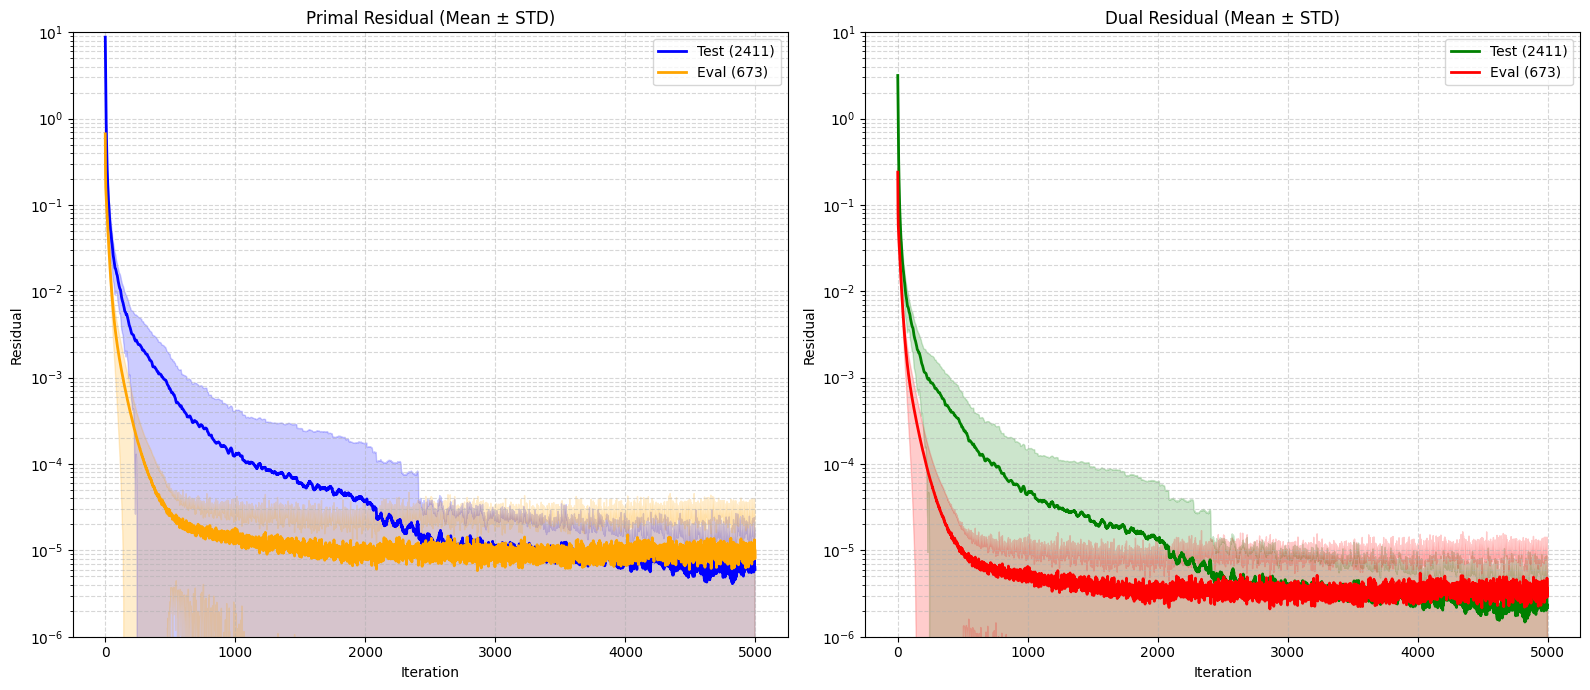

In [ ]:
def plot_with_std(primal_test, primal_eval, dual_test, dual_eval):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

    def add_shaded_line(ax, data, label, color):
        # Calculate statistics across the 100 scenarios (axis 0)
        mean = np.nanmean(data, axis=0)
        std = np.nanstd(data, axis=0)
        x = np.arange(len(mean))
        
        # Plot the main Mean line
        ax.plot(x, mean, label=label, color=color, linewidth=2)
        
        # Plot the shaded STD area
        # Use alpha=0.2 to make it transparent
        ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.2)

    # --- Plot 1: Primal ---
    add_shaded_line(ax1, primal_test, "Test (2411)", "blue")
    add_shaded_line(ax1, primal_eval, "Eval (673)", "orange")
    ax1.set_title("Primal Residual (Mean ± STD)")
    ax1.set_yscale('log')
    ax1.legend()
    ax1.set_ylim(10e-7,10)

    # --- Plot 2: Dual ---
    add_shaded_line(ax2, dual_test, "Test (2411)", "green")
    add_shaded_line(ax2, dual_eval, "Eval (673)", "red")
    ax2.set_title("Dual Residual (Mean ± STD)")
    ax2.set_yscale('log')
    ax2.legend()
    ax2.set_ylim(10e-7,10)

    for ax in [ax1, ax2]:
        ax.set_xlabel("Iteration")
        ax.set_ylabel("Residual")
        ax.grid(True, which="both", linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

# Run the plot
plot_with_std(primal_test, primal_eval, dual_test, dual_eval)

C:\Users\PC\AppData\Local\Temp\ipykernel_78356\1761540851.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


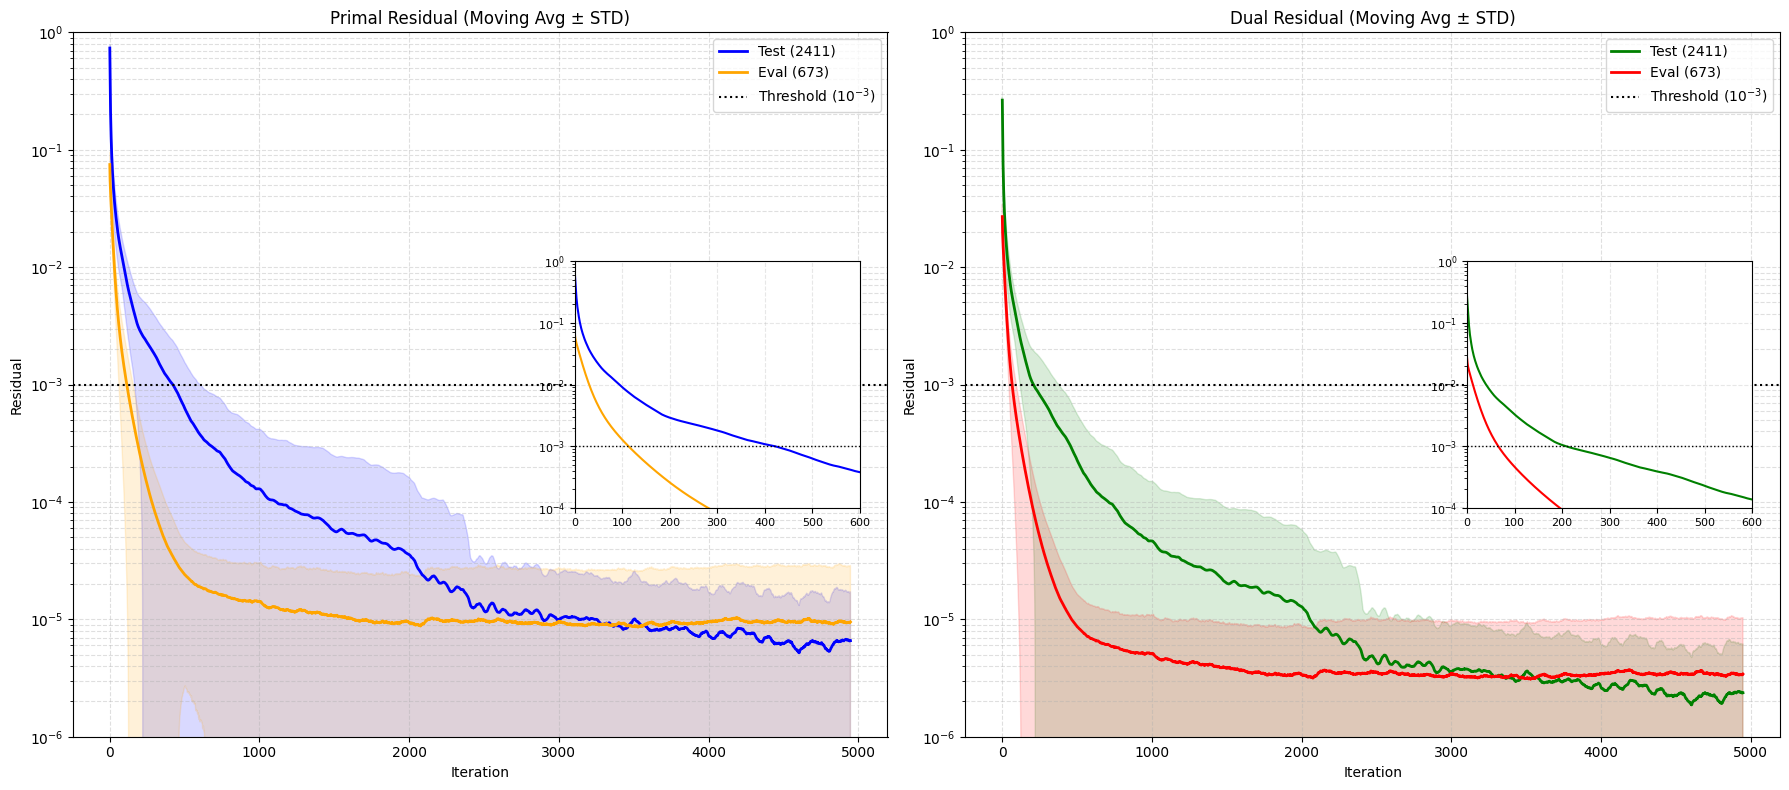

In [24]:
plot_with_std(primal_test, primal_eval, dual_test, dual_eval)

# Dataset distribution

In [36]:
dataset = r'D:\Jacky\Data Output\ADMM_P2P\Database\Train\LP_PrioGO_train_InterGen_1000sce'
with open(f'{testdatapath}/config_generalization.json', 'r') as file:
    config_gen = json.load(file)
users = np.array([c['num_users'] for c in config_gen])

total_count = len(users)

# 2. Filter using boolean masking
low_occ  = np.sum(users <= 10)
mid_occ  = np.sum((users > 10) & (users <= 20))
high_occ = np.sum(users > 20)  # Note: 21 and above

# 3. Calculate proportions
prop_low  = low_occ / total_count
prop_mid  = mid_occ / total_count
prop_high = high_occ / total_count

# 4. Print results (formatted as percentages)
print('--------------------------------------------')
print('Training dataset occupation distribution:')
print(f"Low Occupation (<=10):  {prop_low:.2%}")
print(f"Mid Occupation (11-20): {prop_mid:.2%}")
print(f"High Occupation (>20):  {prop_high:.2%}")

--------------------------------------------
Training dataset occupation distribution:
Low Occupation (<=10):  28.00%
Mid Occupation (11-20): 35.00%
High Occupation (>20):  37.00%


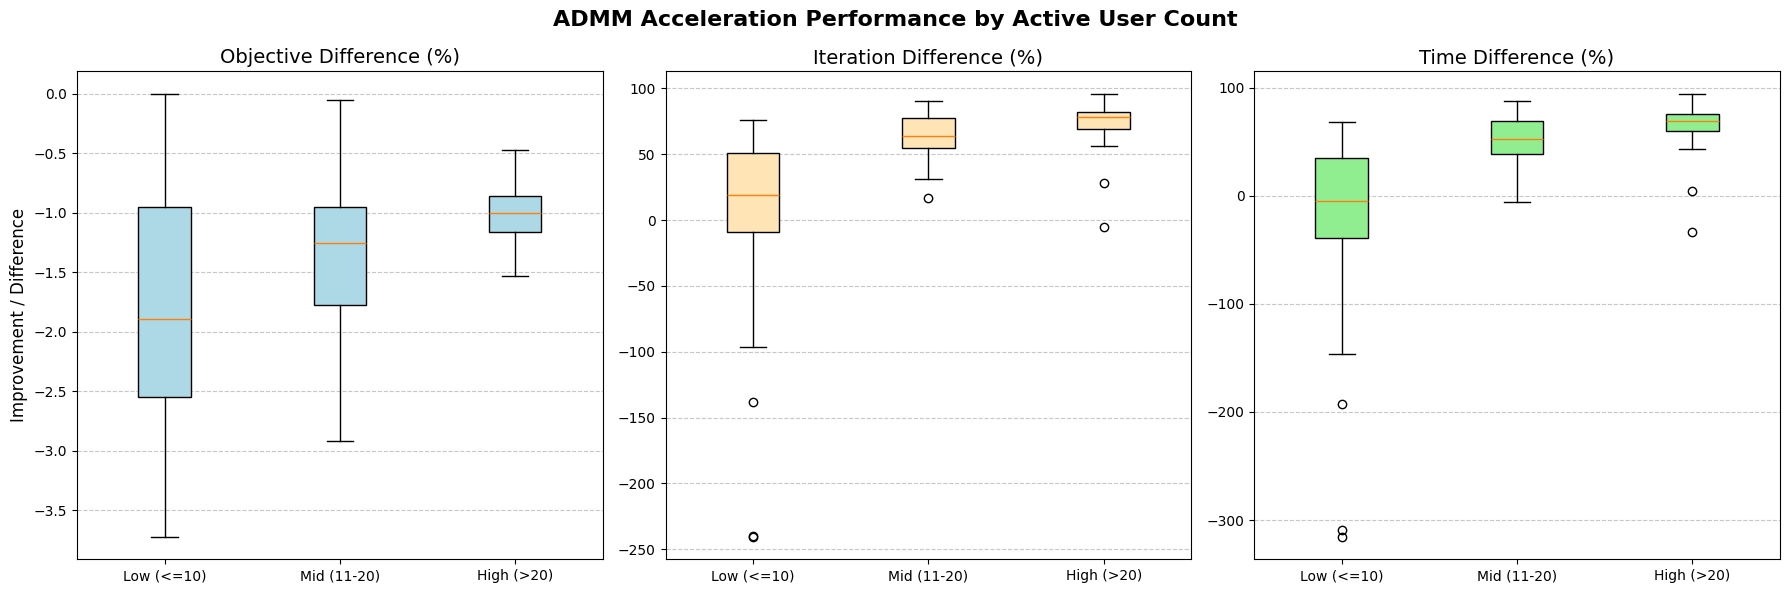

In [42]:
testdatapath = r"D:\Jacky\Data Output\ADMM_P2P\Database\Test and Eval\LP_PrioGO_test_InterGen_100sce"
evaldatapath = r"D:\Jacky\Data Output\ADMM_P2P\Database\Test and Eval\Eval_TransT4-500epochs_InterGen_raw_beforePros_proximal_WS_100sce"

with open(f'{testdatapath}/config.json', 'r') as file:
    config_test = json.load(file)
start_sce_save, end_sce_save = config_test["sce_start"], config_test["sce_end"]
# gather_results(testdatapath, start_sce_save, end_sce_save)
with open(f'{evaldatapath}/config.json', 'r') as file:
    config_eval = json.load(file)
start_sce_save, end_sce_save = config_eval["sce_start"], config_eval["sce_end"]
# gather_results(evaldatapath, start_sce_save, end_sce_save)

if config_test["save_csv"]:
    start_sce_test, end_sce_test = config_test["sce_start"], config_test["sce_end"]
    iter_test = pd.read_csv(f"{testdatapath}/optimal_iter/optimal_iter_{start_sce_test}to{end_sce_test}sce.csv").values.flatten()
    obj_test = pd.read_csv(f"{testdatapath}/optimal_iter/objective_value_{start_sce_test}to{end_sce_test}sce.csv").values
    time_test = pd.read_csv(f"{testdatapath}/optimal_iter/execution_time_{start_sce_test}to{end_sce_test}sce.csv").values.flatten()

    indices = [int(x-2) for x in iter_test]
    opt_obj_test = np.array([obj_test[sce, i] for sce, i in enumerate(indices)])
else:
    iter_test = np.load(f"{testdatapath}/optimal_iter/conv_iter.npz")
    obj_test = np.load(f"{testdatapath}/optimal_iter/obj_var.npz")
    time_test = np.load(f"{testdatapath}/optimal_iter/runtime.npz")

    indices = [int(x-2) for x in iter_test]
    opt_obj_test = np.array([obj_test[sce, i] for sce, i in enumerate(indices)])

if config_eval["save_csv"]:
    start_sce_eval, end_sce_eval = config_eval["sce_start"], config_eval["sce_end"]
    iter_eval = pd.read_csv(f"{evaldatapath}/optimal_iter/optimal_iter_{start_sce_eval}to{end_sce_eval}sce.csv").values.flatten()
    obj_eval = pd.read_csv(f"{evaldatapath}/optimal_iter/objective_value_{start_sce_eval}to{end_sce_eval}sce.csv").values
    time_eval = pd.read_csv(f"{evaldatapath}/optimal_iter/execution_time_{start_sce_eval}to{end_sce_eval}sce.csv").values.flatten()

    indices = [int(x-2) for x in iter_eval]
    opt_obj_eval = np.array([obj_eval[sce, i] for sce, i in enumerate(indices)])
else:
    iter_eval = np.load(f"{evaldatapath}/optimal_iter/conv_iter.npz")
    obj_eval = np.load(f"{evaldatapath}/optimal_iter/obj_var.npz")
    time_eval = np.load(f"{evaldatapath}/optimal_iter/runtime.npz")

    indices = [int(x-2) for x in iter_eval]
    opt_obj_eval = np.array([obj_eval[sce, i] for sce, i in enumerate(indices)])

num_users_list = []

if os.path.isfile(f'{testdatapath}/config_generalization.json'):
    with open(f'{testdatapath}/config_generalization.json', 'r') as file:
        config_gen = json.load(file)
    num_users_list = np.array([c['num_users'] for c in config_gen])

# 1. Create a dictionary to map data to column names
data = {
    'obj_diff': (opt_obj_test - opt_obj_eval)/opt_obj_test * 100,
    'iter_diff': (iter_test - iter_eval)/iter_test * 100,
    'time_diff': (time_test - time_eval)/time_test * 100,
}

low_user_obj_diff = data['obj_diff'][num_users_list <= 10]
mid_user_obj_diff = data['obj_diff'][(num_users_list > 10) & (num_users_list <= 20)]
high_user_obj_diff = data['obj_diff'][num_users_list > 20]

low_user_iter_diff = data['iter_diff'][num_users_list <= 10]
mid_user_iter_diff = data['iter_diff'][(num_users_list > 10) & (num_users_list <= 20)]
high_user_iter_diff = data['iter_diff'][num_users_list > 20]

low_user_time_diff = data['time_diff'][num_users_list <= 10]
mid_user_time_diff = data['time_diff'][(num_users_list > 10) & (num_users_list <= 20)]
high_user_time_diff = data['time_diff'][num_users_list > 20]

import matplotlib.pyplot as plt

# Group your sliced variables together for plotting
obj_data = [low_user_obj_diff, mid_user_obj_diff, high_user_obj_diff]
iter_data = [low_user_iter_diff, mid_user_iter_diff, high_user_iter_diff]
time_data = [low_user_time_diff, mid_user_time_diff, high_user_time_diff]

# Labels for the x-axis
labels = ['Low (<=10)', 'Mid (11-20)', 'High (>20)']

# Set up a figure with 3 side-by-side subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Plot 1: Objective Difference ---
# If your data is in PyTorch tensors, you might need to add .cpu().numpy() to the variables, 
# e.g., [x.cpu().numpy() for x in obj_data]
axes[0].boxplot(obj_data, labels=labels, patch_artist=True, boxprops=dict(facecolor="lightblue"))
axes[0].set_title('Objective Difference (%)', fontsize=14)
axes[0].set_ylabel('Improvement / Difference', fontsize=12)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# --- Plot 2: Iteration Difference ---
axes[1].boxplot(iter_data, labels=labels, patch_artist=True, boxprops=dict(facecolor="moccasin"))
axes[1].set_title('Iteration Difference (%)', fontsize=14)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# --- Plot 3: Time Difference ---
axes[2].boxplot(time_data, labels=labels, patch_artist=True, boxprops=dict(facecolor="lightgreen"))
axes[2].set_title('Time Difference (%)', fontsize=14)
axes[2].grid(axis='y', linestyle='--', alpha=0.7)

# Add a main title for the whole figure
fig.suptitle('ADMM Acceleration Performance by Active User Count', fontsize=16, fontweight='bold')

# Adjust layout and show
plt.tight_layout()
plt.show()